# Chapter 269 - Hidden Markov Models

**Part VIII - Probability**

A Markov chain (ch257) lets us model sequences of states. But in many real problems the states are hidden: we observe noisy measurements but not the underlying process directly. Hidden Markov Models (HMMs) combine the Markov structure with probabilistic observations, enabling three fundamental inference tasks: computing sequence likelihood, decoding the most probable state sequence, and learning parameters from data.

## 1. HMM Structure and Parameters

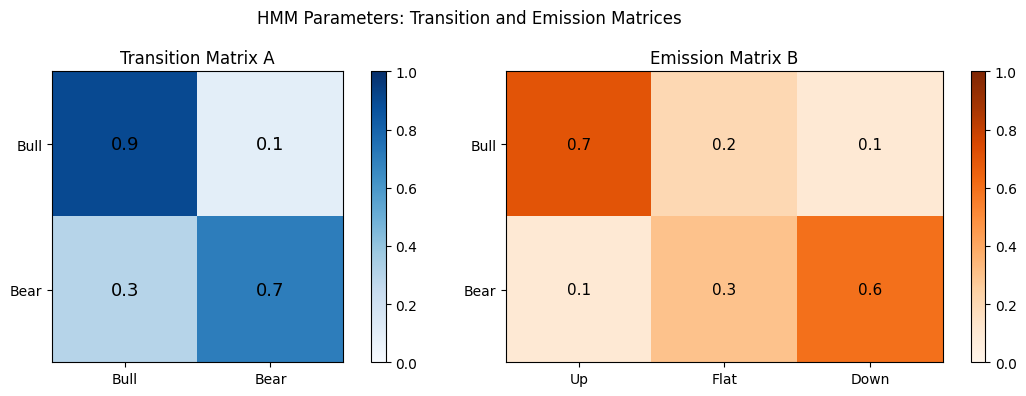

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(99)

# Hidden Markov Model structure:
# - Hidden states: S_t in {0, 1, ..., K-1}  (Markov chain, ch257)
# - Observations: O_t depends only on S_t
#
# Parameters:
# - pi: initial state distribution (K,)
# - A: transition matrix (K, K), A[i,j] = P(S_{t+1}=j | S_t=i)
# - B: emission matrix (K, V) for discrete obs, or emission parameters for continuous

K = 2    # number of hidden states (e.g., "bull" and "bear" market)
V = 3    # observation vocabulary (e.g., "up", "flat", "down")

# Define a simple HMM for market states
pi = np.array([0.6, 0.4])   # initial: more likely in state 0

A = np.array([
    [0.9, 0.1],   # state 0 (bull): tends to stay bull
    [0.3, 0.7],   # state 1 (bear): tends to stay bear
])

B = np.array([
    [0.7, 0.2, 0.1],  # bull -> likely "up"
    [0.1, 0.3, 0.6],  # bear -> likely "down"
])

labels_states = ["Bull", "Bear"]
labels_obs    = ["Up", "Flat", "Down"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(A, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Transition Matrix A"); plt.colorbar(im0, ax=axes[0])
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(labels_states); axes[0].set_yticklabels(labels_states)
for i in range(K):
    for j in range(K):
        axes[0].text(j, i, f"{A[i,j]:.1f}", ha="center", va="center", fontsize=13)

im1 = axes[1].imshow(B, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Emission Matrix B"); plt.colorbar(im1, ax=axes[1])
axes[1].set_xticks(range(V)); axes[1].set_yticks(range(K))
axes[1].set_xticklabels(labels_obs); axes[1].set_yticklabels(labels_states)
for i in range(K):
    for j in range(V):
        axes[1].text(j, i, f"{B[i,j]:.1f}", ha="center", va="center", fontsize=11)

plt.suptitle("HMM Parameters: Transition and Emission Matrices")
plt.tight_layout(); plt.show()


## 2. Generating Sequences from an HMM

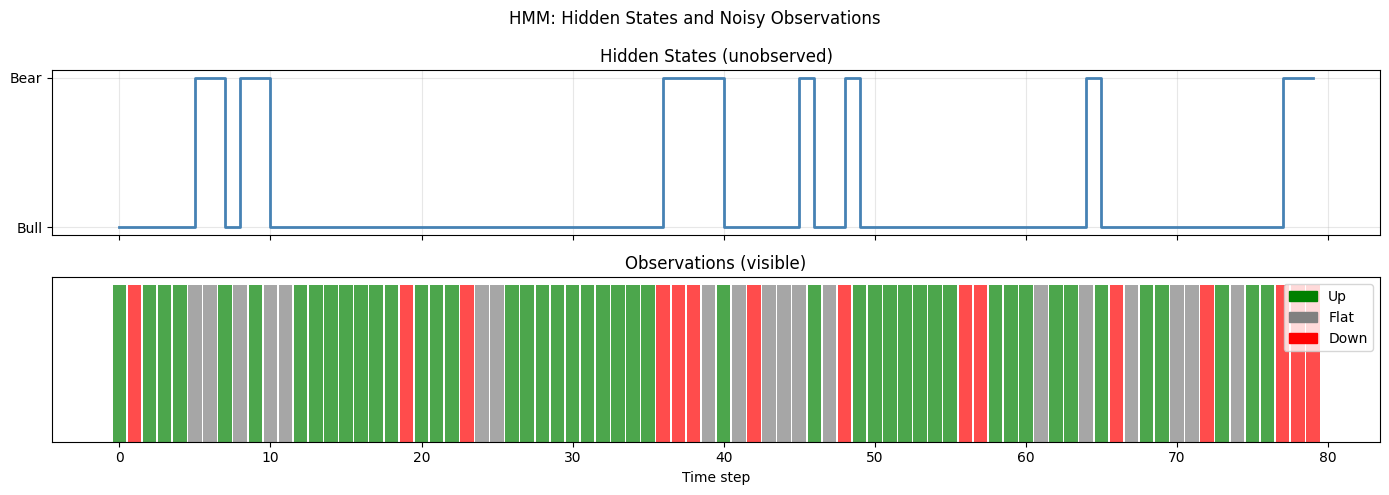

Bull (state 0): 66 steps | Bear (state 1): 14 steps


In [2]:
def hmm_sample(pi, A, B, T, rng):
    K = len(pi)
    states = np.zeros(T, dtype=int)
    obs    = np.zeros(T, dtype=int)
    states[0] = rng.choice(K, p=pi)
    obs[0]    = rng.choice(B.shape[1], p=B[states[0]])
    for t in range(1, T):
        states[t] = rng.choice(K, p=A[states[t-1]])
        obs[t]    = rng.choice(B.shape[1], p=B[states[t]])
    return states, obs

T = 80
true_states, observations = hmm_sample(pi, A, B, T, rng)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(true_states, drawstyle="steps-post", color="steelblue", lw=2)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(labels_states)
axes[0].set_title("Hidden States (unobserved)"); axes[0].grid(alpha=0.3)

obs_colors = ["green", "gray", "red"]
for t, (o, s) in enumerate(zip(observations, true_states)):
    axes[1].bar(t, 1, color=obs_colors[o], alpha=0.7, width=0.9)
axes[1].set_title("Observations (visible)")
axes[1].set_yticks([]); axes[1].set_xlabel("Time step")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=obs_colors[i], label=labels_obs[i]) for i in range(V)])
plt.suptitle("HMM: Hidden States and Noisy Observations")
plt.tight_layout(); plt.show()
print(f"Bull (state 0): {np.sum(true_states==0)} steps | Bear (state 1): {np.sum(true_states==1)} steps")


## 3. The Forward Algorithm - Computing Sequence Likelihood

Naive computation of P(O) requires summing over all K^T state sequences: exponential cost. Dynamic programming reduces this to O(K^2 T).

P(observations) = 2.601230e-34
log P(observations) = -77.3319


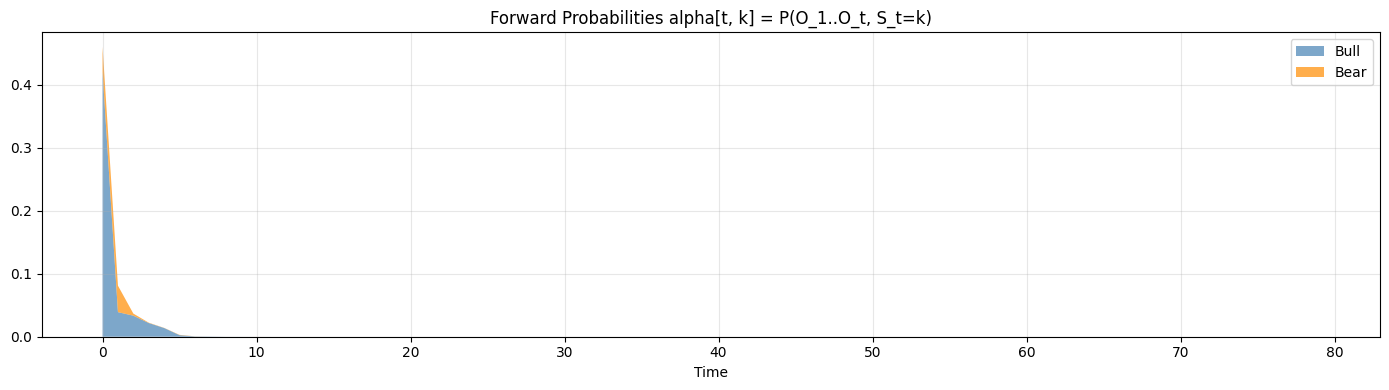

In [3]:
# Forward algorithm: compute P(O_{1:t}, S_t = k) efficiently via dynamic programming
# alpha[t, k] = P(O_1,...,O_t, S_t = k)
# Base: alpha[0, k] = pi[k] * B[k, O_0]
# Recursion: alpha[t, k] = B[k, O_t] * sum_j(alpha[t-1, j] * A[j, k])

def forward(pi, A, B, obs):
    T = len(obs)
    K = len(pi)
    alpha = np.zeros((T, K))
    alpha[0] = pi * B[:, obs[0]]
    for t in range(1, T):
        alpha[t] = B[:, obs[t]] * (alpha[t-1] @ A)
    return alpha

alpha = forward(pi, A, B, observations)
likelihood = alpha[-1].sum()
print(f"P(observations) = {likelihood:.6e}")
print(f"log P(observations) = {np.log(likelihood):.4f}")

# Visualize forward probabilities over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(range(T), alpha[:, 0], alpha[:, 1],
             labels=labels_states, alpha=0.7, colors=["steelblue", "darkorange"])
ax.set_title("Forward Probabilities alpha[t, k] = P(O_1..O_t, S_t=k)")
ax.set_xlabel("Time"); ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. The Viterbi Algorithm - Decoding Hidden States

Viterbi finds the single most probable state sequence using the same DP structure as forward, but with max instead of sum. Log-domain computation prevents underflow. *(Dynamic programming from ch257 - Markov Chains)*

Viterbi state accuracy: 0.887


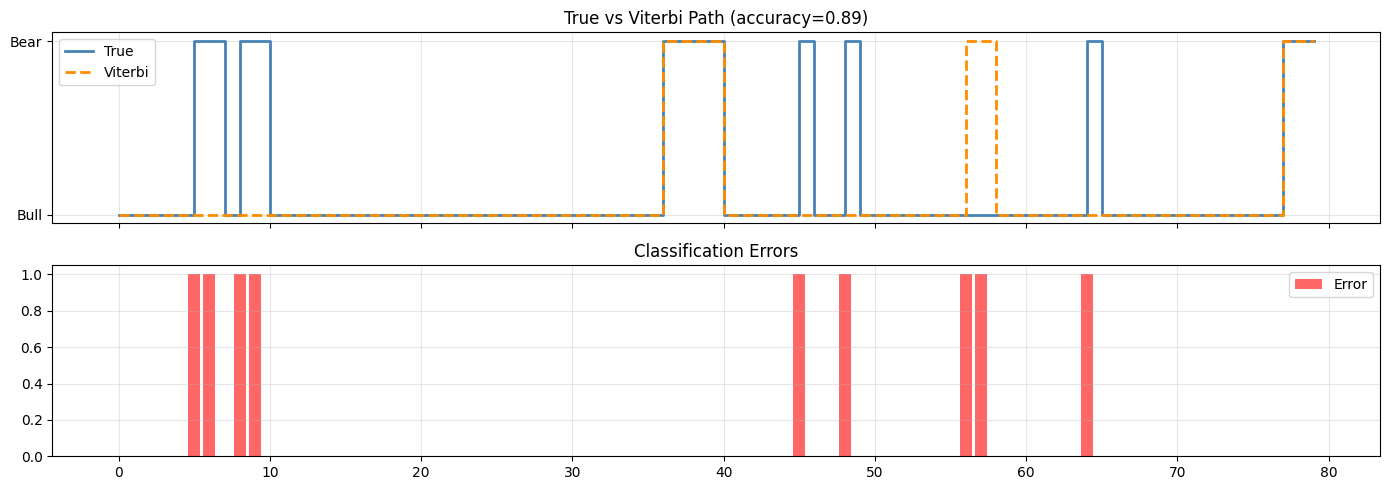

In [4]:
# Viterbi algorithm: find most likely state sequence
# delta[t, k] = max_{s_{1:t-1}} P(s_{1:t-1}, S_t=k, O_{1:t})
# psi[t, k] = argmax_j delta[t-1, j] * A[j,k]  (backpointer)

def viterbi(pi, A, B, obs):
    T = len(obs)
    K = len(pi)
    log_A = np.log(A + 1e-300)
    log_B = np.log(B + 1e-300)
    log_pi = np.log(pi + 1e-300)

    delta = np.full((T, K), -np.inf)
    psi   = np.zeros((T, K), dtype=int)

    delta[0] = log_pi + log_B[:, obs[0]]
    for t in range(1, T):
        for k in range(K):
            scores = delta[t-1] + log_A[:, k]
            psi[t, k]   = np.argmax(scores)
            delta[t, k] = scores[psi[t, k]] + log_B[k, obs[t]]

    # Backtrack
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path, delta

viterbi_path, delta = viterbi(pi, A, B, observations)

# Compare Viterbi path vs true hidden states
accuracy = np.mean(viterbi_path == true_states)
print(f"Viterbi state accuracy: {accuracy:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].step(range(T), true_states, where="post", label="True", lw=2, color="steelblue")
axes[0].step(range(T), viterbi_path, where="post", label="Viterbi", lw=2,
             ls="--", color="darkorange")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(labels_states)
axes[0].legend(); axes[0].set_title(f"True vs Viterbi Path (accuracy={accuracy:.2f})")
axes[0].grid(alpha=0.3)

errors = (viterbi_path != true_states).astype(int)
axes[1].bar(range(T), errors, color="red", alpha=0.6, label="Error")
axes[1].set_title("Classification Errors"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Gaussian HMMs - Continuous Observations

Replacing discrete emission distributions with Gaussians extends HMMs to continuous data: speech features, financial returns, sensor readings.

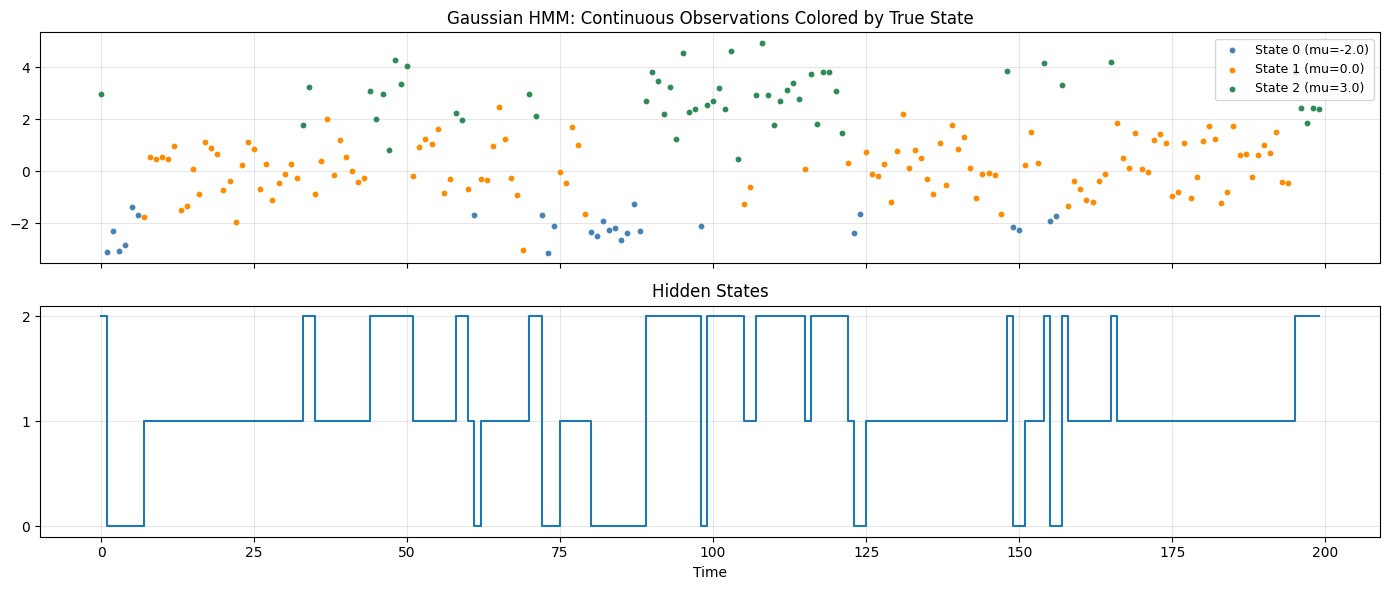

In practice, HMM parameters are estimated with the Baum-Welch EM algorithm.
This connects to ch246 (Bayes) and ch257 (Markov Chains).


In [5]:
# Gaussian HMM: continuous observations from Gaussian emission distributions
# Each state k emits: X_t | S_t=k ~ N(mu_k, sigma_k^2)
# Common in speech recognition, finance, bioinformatics

K_g = 3
mu_emit   = np.array([-2.0, 0.0, 3.0])
sig_emit  = np.array([0.5, 1.0, 0.8])

A_g = np.array([
    [0.8, 0.15, 0.05],
    [0.1, 0.8,  0.1 ],
    [0.05, 0.15, 0.8],
])
pi_g = np.array([0.4, 0.4, 0.2])

def gaussian_hmm_sample(pi, A, mu, sig, T, rng):
    K = len(pi)
    states = np.zeros(T, dtype=int)
    obs    = np.zeros(T)
    states[0] = rng.choice(K, p=pi)
    obs[0]    = rng.normal(mu[states[0]], sig[states[0]])
    for t in range(1, T):
        states[t] = rng.choice(K, p=A[states[t-1]])
        obs[t]    = rng.normal(mu[states[t]], sig[states[t]])
    return states, obs

T_g = 200
g_states, g_obs = gaussian_hmm_sample(pi_g, A_g, mu_emit, sig_emit, T_g, rng)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
colors_g = ["steelblue", "darkorange", "seagreen"]
for k in range(K_g):
    mask = g_states == k
    t_idx = np.where(mask)[0]
    axes[0].scatter(t_idx, g_obs[t_idx], s=10, color=colors_g[k],
                    label=f"State {k} (mu={mu_emit[k]})", zorder=3)
axes[0].set_title("Gaussian HMM: Continuous Observations Colored by True State")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].step(range(T_g), g_states, where="post", lw=1.5)
axes[1].set_yticks(range(K_g)); axes[1].set_title("Hidden States")
axes[1].set_xlabel("Time"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("In practice, HMM parameters are estimated with the Baum-Welch EM algorithm.")
print("This connects to ch246 (Bayes) and ch257 (Markov Chains).")


## 6. Summary

HMM inference algorithms:

| Algorithm | Question answered | Complexity |
|---|---|---|
| Forward | P(observations) | O(K^2 T) |
| Forward-Backward | P(S_t | obs) marginals | O(K^2 T) |
| Viterbi | argmax P(states, obs) | O(K^2 T) |
| Baum-Welch | MLE parameter estimation | O(K^2 T) per iteration |

*(builds on ch257 - Markov Chains, ch246 - Bayes Theorem, ch245 - Conditional Probability)*

## 7. Forward References

- **ch271 - Data and Measurement**: sequential data preprocessing for HMM inputs.
- **ch288 - Classification**: HMMs as sequence classifiers vs discriminative models.
- **ch299 - Capstone**: sequence modeling as a component of end-to-end AI pipelines.